<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

## **Proyecto Boosting de Algoritmos**

**Autora:** Anais Aponte  
**Bootcamp:** 4Geeks Academy – Intro to Machine Learning  
**Proyecto:** Proyecto Boosting de Algoritmos  

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Instrucciones**

#### **Prediciendo la diabetes**

**Objetivo**: En este proyecto el objetivo es mejorar el modelo realizado en el proyecto de random forest para aumentar el accuracy.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Paso 1: Carga del conjunto de datos**

El dataset utilizado en este proyecto es **diabetes.csv**.

Para facilitar la reproducibilidad y evitar dependencias externas, el archivo ha sido previamente descargado y almacenado dentro del repositorio en la siguiente ruta:

📁 `data/raw/diabetes.csv`

De esta forma, el notebook puede ejecutarse directamente sin necesidad de acceder a enlaces externos.

A continuación se realizan primero las importaciones necesarias y, posteriormente, la carga del dataset para iniciar el análisis.

</div>

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocesamiento
from sklearn.impute import SimpleImputer
# División de datos
from sklearn.model_selection import train_test_split
# Modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# Métricas
from sklearn.metrics import accuracy_score
# Reporte
from sklearn.metrics import classification_report
# Importamos la librería para guardar modelos
import joblib


In [2]:
# CARGAMOS EL FICHERO CON LOS DATOS A ANALIZAR
df = pd.read_csv('../data/raw/diabetes.csv')

# Visualizamos 10 registros aleatorios del dataset con sample(). Esto nos permite observar una muestra representativa de los datos,
# ya que algunos datasets pueden estar ordenados (por fecha, id, etc.).
df.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
126,3,120,70,30,135,42.9,0.452,30,0
274,13,106,70,0,0,34.2,0.251,52,0
130,4,173,70,14,168,29.7,0.361,33,1
582,12,121,78,17,0,26.5,0.259,62,0
374,2,122,52,43,158,36.2,0.816,28,0
136,0,100,70,26,50,30.8,0.597,21,0
725,4,112,78,40,0,39.4,0.236,38,0
693,7,129,68,49,125,38.5,0.439,43,1
206,8,196,76,29,280,37.5,0.605,57,1
619,0,119,0,0,0,32.4,0.141,24,1


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 1.1: Limpiar nulos (ceros)**

</div>

In [3]:
# Creamos una copia del dataset para trabajar sin modificar el original
df_sinceros = df.copy()

In [4]:
# Reemplazamos los valores 0 por NaN en variables donde no son fisiológicamente posibles
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zeros:
    df_sinceros[col] = df_sinceros[col].replace(0, np.nan)

In [5]:
# Imputamos los valores faltantes utilizando la mediana para evitar sesgos por outliers

imputer = SimpleImputer(strategy='median')
df_sinceros[cols_with_zeros] = imputer.fit_transform(df_sinceros[cols_with_zeros])


In [6]:
# Verificamos el número de ceros en todas las variables tras el tratamiento
ceros_sinceros = (df_sinceros == 0).sum()

ceros_sinceros

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 1.2: Separar X y y**

</div>

In [7]:
# Separamos variables predictoras (X) y variable objetivo (y)
X = df_sinceros.drop(columns='Outcome')
y = df_sinceros['Outcome']

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 1.3: Train / Test split**

</div>

In [8]:
# Dividimos los datos en entrenamiento y test manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1,90.0,62.0,12.0,43.0,27.2,0.580,24
711,5,126.0,78.0,27.0,22.0,29.6,0.439,40
373,2,105.0,58.0,40.0,94.0,34.9,0.225,25
46,1,146.0,56.0,29.0,125.0,29.7,0.564,29
682,0,95.0,64.0,39.0,105.0,44.6,0.366,22


--------

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2: Construye un modelo Boosting XGBoost (eXtreme Gradient Boosting)**

</div>

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Elección de la implementación de boosting**

Para este proyecto se ha utilizado `XGBClassifier` de la librería `xgboost` en vez d ela de `sklearn`, ya que representa una implementación optimizada del algoritmo de Gradient Boosting.

</div>

In [9]:
# Entrenamos el modelo con los valores por defecto a saber: 
# n_estimators = 100 → número de árboles
# learning_rate = 0.3 → cuánto corrige cada nuevo árbol
# max_depth = 6 → profundidad máxima de cada árbol
# subsample = 1 → usa todo el dataset en cada iteración
# colsample_bytree = 1 → usa todas las variables
# gamma = 0 → no penaliza divisiones
# min_child_weight = 1 → mínimo peso en hojas
# reg_alpha = 0 → sin regularización L1
# reg_lambda = 1 → regularización L2

model_base = XGBClassifier(random_state = 42)
model_base.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Nota:**

Los valores por defecto de los hiperparámetros se obtienen de la documentación oficial de la librería XGBoost, ya que algunos aparecen como `None` al instanciar el modelo, pero internamente utilizan valores predefinidos.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.1: Predecimos y medimos el modelo base**

</div>

In [10]:
# Generamos las predicciones del modelo base sobre el conjunto de test
y_pred_base = model_base.predict(X_test)
y_pred_base

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0])

In [11]:
# Vemos cuanto es el accuracy de este modelo
acc_base = accuracy_score(y_test, y_pred_base)
acc_base

0.7597402597402597

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación**

El modelo base de XGBoost no supera inicialmente a los modelos anteriores en términos de accuracy. Esto sugiere que, aunque se trata de una implementación más avanzada de boosting, su rendimiento depende en mayor medida del ajuste de hiperparámetros propios del algoritmo. 


</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2.2: Probar con hiperparametros**

</div>

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Nota**

Se van a modificar solo estos hiperparametros: `n_estimators`, `learning_rate`, `subsample` y la función objetivo (`objective`) por que son hacen referencia al boosting. Sin embargo como la función objetivo (`objective`) suele venir configurada correctamente por defecto para problemas de clasificación binaria se dejara con su valor por defecto.

In [12]:
# Creamos una lista vacía para guardar los resultados de cada combinación
results = []

# Definimos los valores que queremos probar para los hiperparámetros propios del boosting
n_estimators_list = [50, 100, 200]      # Número de árboles
learning_rate_list = [0.01, 0.1, 0.3]  # Intensidad con la que cada nuevo árbol corrige errores
subsample_list = [0.7, 1.0]            # Proporción de datos usada en cada iteración

# Recorremos todas las combinaciones posibles de hiperparámetros
for n in n_estimators_list:
    for lr in learning_rate_list:
        for sub in subsample_list:

            # Creamos un modelo temporal con la combinación actual
            model_temp = XGBClassifier(
                n_estimators=n,
                learning_rate=lr,
                subsample=sub,
                random_state=42
            )

            # Entrenamos el modelo con los datos de entrenamiento
            model_temp.fit(X_train, y_train)

            # Generamos predicciones sobre el conjunto de test
            y_pred_temp = model_temp.predict(X_test)

            # Calculamos el accuracy del modelo
            acc = accuracy_score(y_test, y_pred_temp)

            # Guardamos los resultados junto con los hiperparámetros utilizados
            results.append({
                "n_estimators": n,
                "learning_rate": lr,
                "subsample": sub,
                "accuracy": acc
            })

# Convertimos la lista de resultados en un DataFrame para facilitar su análisis
results_df = pd.DataFrame(results)
results_df

,n_estimators,learning_rate,subsample,accuracy
0,50,0.01,0.7,0.707792
1,50,0.01,1.0,0.720779
2,50,0.10,0.7,0.727273
3,50,0.10,1.0,0.753247
4,50,0.30,0.7,0.727273
5,50,0.30,1.0,0.753247
6,100,0.01,0.7,0.740260
7,100,0.01,1.0,0.746753
8,100,0.10,0.7,0.727273
9,100,0.10,1.0,0.746753


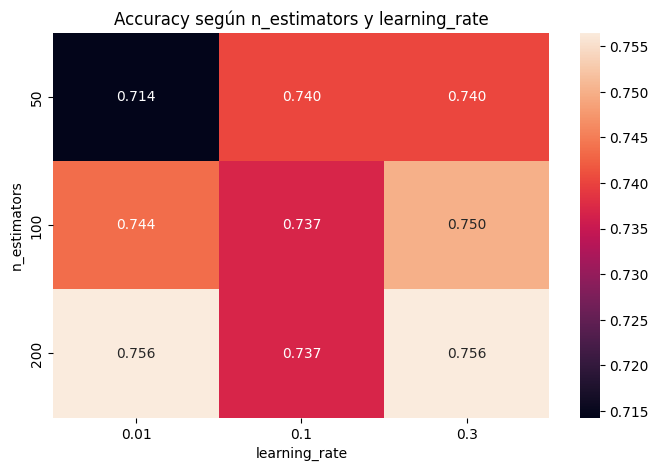

In [13]:
# Pivot para visualizar mejor
pivot_table = results_df.pivot_table(
    values="accuracy",
    index="n_estimators",
    columns="learning_rate"
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot_table, annot=True, fmt=".3f")
plt.title("Accuracy según n_estimators y learning_rate")
plt.ylabel("n_estimators")
plt.xlabel("learning_rate")
plt.show()

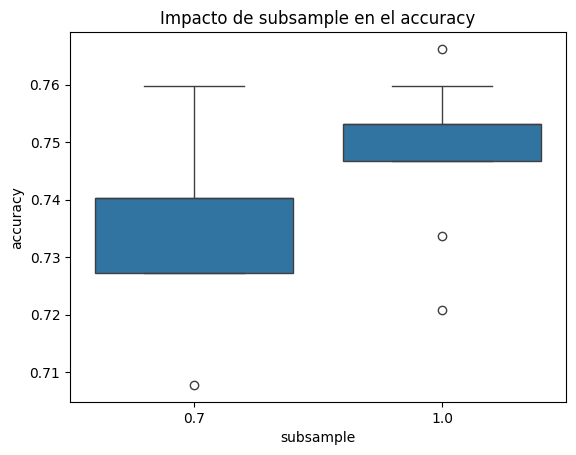

In [14]:
sns.boxplot(data=results_df, x="subsample", y="accuracy")
plt.title("Impacto de subsample en el accuracy")
plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Nota:**

A partir de los gráficos, se observa que el modelo mejora su rendimiento al aumentar el número de árboles (`n_estimators = 200`). Asimismo, los valores extremos de `learning_rate` (0.01 y 0.3) ofrecen mejores resultados que valores intermedios en este caso.

Por otro lado, el análisis del parámetro `subsample` muestra que utilizar el 100% de los datos (`subsample = 1.0`) tiende a generar modelos más precisos y estables, mientras que el uso de subconjuntos aleatorios introduce mayor variabilidad y reduce ligeramente el rendimiento.


</div>

<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Conclusión probar con hiperparametros**

Tras comparar los tres modelos implementados (Decision Tree, Random Forest y XGBoost), se observa que el árbol de decisión ajustado con `criterion='entropy'` obtiene el mejor rendimiento en términos de accuracy.

A pesar de utilizar modelos más complejos como Random Forest y XGBoost, estos no logran superar al modelo más simple, lo que indica que, para este conjunto de datos, la complejidad adicional no aporta una mejora significativa.

Este resultado pone de manifiesto que la elección del modelo no debe basarse únicamente en su sofisticación, sino en su adecuación al problema y al tamaño del dataset.


</div>

_____________

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3: Guardar el modelo**

</div>

In [15]:
# Guardamos el modelo optimizado
joblib.dump(model_base, '../models/xgboost_diabetes_base.sav')

['../models/xgboost_diabetes_base.sav']

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Nota**

Se almacena el modelo base de XGBoost entrenado con parametros por defecto para cumplir con este paso del proyecto. 

</div>

_____

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 4: Analiza y compara los resultados de los modelos**

</div>

In [16]:
# Decision Tree
tree = DecisionTreeClassifier(criterion='entropy', max_depth=7, min_samples_leaf=10, min_samples_split=2, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

In [20]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, bootstrap=True, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [18]:
boost = XGBClassifier(n_estimators=200, learning_rate=0.01, subsample=1.0,random_state=42)
boost.fit(X_train, y_train)

y_pred_boost = boost.predict(X_test)

In [19]:
print("Decision Tree")
print(classification_report(y_test, y_pred_tree))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

print("XGBoost")
print(classification_report(y_test, y_pred_boost))

Decision Tree
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       100
           1       0.75      0.56      0.64        54

    accuracy                           0.78       154
   macro avg       0.77      0.73      0.74       154
weighted avg       0.78      0.78      0.77       154

Random Forest
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154

XGBoost
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       100
           1       0.70      0.57      0.63        54

    accuracy                           0.77       154
   macro avg       0.75      0.72      0.73       154
weighted avg       0.76      0.77     

In [21]:
acc_tree = accuracy_score(y_test, y_pred_tree)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_xgb = accuracy_score(y_test, y_pred_boost)

print("Decision Tree:", acc_tree)
print("Random Forest:", acc_rf)
print("XGBoost:", acc_xgb)

Decision Tree: 0.7792207792207793
Random Forest: 0.7792207792207793
XGBoost: 0.7662337662337663


<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Comparación de modelos y selección final**

Tras evaluar los tres modelos, se observa que Decision Tree y Random Forest alcanzan el mismo valor de accuracy, lo que indica un rendimiento global equivalente.

Sin embargo, al analizar las métricas por clase, el modelo Random Forest presenta una ligera mejora en el recall de la clase 1, lo que indica una mayor capacidad para identificar correctamente los casos positivos de diabetes.

En un contexto médico, este aspecto resulta especialmente crítico, ya que los falsos negativos (no detectar a un paciente con diabetes) pueden tener consecuencias graves.

Por este motivo, **se selecciona el modelo Random Forest como modelo final, priorizando su mejor capacidad para detectar casos positivos**, aunque implique un modelo más complejo.

</div>